## Importing Modules

In [46]:
import torch.nn as nn                                
import torch
import torch.nn.functional as F
import math
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import fasttext
from transformers import AutoTokenizer
import os

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Encoder Block

In [3]:
class MHA(nn.Module):
    def __init__(self,d_model,num_heads,dropout=0.1,bias=False):
        super().__init__()

        assert d_model%num_heads==0, "Model dimensions should be a multiple of number of heads"
        
        self.d_model=d_model
        self.num_heads=num_heads
        self.W_query=nn.Linear(d_model,d_model,bias)
        self.W_key=nn.Linear(d_model,d_model,bias)
        self.W_value=nn.Linear(d_model,d_model,bias)
        self.d_k=d_model//num_heads
        self.W_O=nn.Linear(d_model,d_model,bias)
        self.dropout=nn.Dropout(p=dropout)
        
    def split_heads(self,x):
        batch_size,seq_length,d_model=x.size()
        return x.view(batch_size,seq_length,self.num_heads,self.d_k).transpose(1, 2)
        
    def combine_heads(self,x):
        batch_size,num_heads,seq_length,d_k=x.size()
        return x.transpose(1, 2).contiguous().view(batch_size,seq_length,self.d_model)

    def forward(self,input,attention_mask):
        query=self.split_heads(self.W_query(input))
        key=self.split_heads(self.W_key(input))
        value=self.split_heads(self.W_value(input))

        scores=(query@key.transpose(-2,-1))/(self.d_k**0.5)
        mask=attention_mask.unsqueeze(1).unsqueeze(2)
        scores=scores.masked_fill(mask == 0, -1e9)
        attn=torch.softmax(scores, dim=-1)
        attn=self.dropout(attn)
        context=attn @ value
        out=self.W_O(self.combine_heads(context))
        return out

In [4]:
class FFN(nn.Module):
    def __init__(self,d_in,mul_factor=4,bias=True):
        super().__init__()
        self.d_in=d_in
        self.d_hidden=int(d_in*mul_factor)
        self.f1=nn.Linear(self.d_in,self.d_hidden,bias)
        self.f2=nn.Linear(self.d_hidden,self.d_in,bias)

    def forward(self,x):
        return self.f2(F.relu(self.f1(x)))

In [5]:
class Encoder(nn.Module):
    def __init__(self,d_model,num_heads,mul_factor=4,dropout=0.1,FFN_bias=True,MHA_bias=False):
        super().__init__()
        self.d_model=d_model
        self.num_heads=num_heads
        self.mul_factor=mul_factor
        self.dropout=nn.Dropout(p=dropout)
        self.MHA_bias=MHA_bias
        self.FFN_bias=FFN_bias

        self.mha=MHA(self.d_model,self.num_heads,dropout,self.MHA_bias)
        self.ffn=FFN(self.d_model,self.mul_factor,self.FFN_bias)

        self.layernorm_attn=nn.LayerNorm(self.d_model)
        self.layernorm_ffn=nn.LayerNorm(self.d_model)

    def forward(self,x,attention_mask):
        batch_size,num_tokens,_=x.size()
        
        attn_out = self.mha(x, attention_mask)
        x = self.layernorm_attn(x + self.dropout(attn_out))

        ffn_out = self.ffn(x)
        x = self.layernorm_ffn(x + self.dropout(ffn_out))
        return x

In [6]:
class Encoder_stack(nn.Module):
    def __init__(self,d_model,num_heads,num_blocks,mul_factor=4,dropout=0.1,FFN_bias=True,MHA_bias=False):
        super().__init__()
        self.d_model=d_model
        self.num_heads=num_heads
        self.mul_factor=mul_factor
        self.num_blocks=num_blocks
        self.dropout=nn.Dropout(p=dropout)
        self.FFN_bias=FFN_bias
        self.MHA_bias=MHA_bias

        self.encoder_stack = nn.ModuleList([Encoder(self.d_model,self.num_heads,self.mul_factor,dropout,self.FFN_bias,self.MHA_bias) for _ in range(self.num_blocks)])

    def forward(self,input,attention_mask):
        key_padding_mask = attention_mask == 0
        encoder_output=input
        for encoder in self.encoder_stack:
            encoder_output=encoder(encoder_output,attention_mask)

        return encoder_output

## Loading Dataset and basic EDA

In [7]:
dir_path="/kaggle/input/dailydialog-multi-turn-dialog-with-intention-and"
train_path=f"{dir_path}/train.csv"

In [8]:
train_df=pd.read_csv(train_path)

In [9]:
train_df.head()

,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]
2,"['Can you study with the radio on ? '\n ' No ,...",[2 1 2 1 1],[0 0 0 0 0]
3,['Are you all right ? '\n ' I will be all righ...,[2 1 1 1],[0 0 0 0]
4,"['Hey John , nice skates . Are they new ? '\n ...",[2 1 2 1 1 2 1 3 4],[0 0 0 0 0 6 0 6 0]


In [10]:
train_df["dialog"]=train_df["dialog"].apply(lambda x: x.replace("[","").replace("]",""))
train_df["dialog"]=train_df["dialog"].apply(lambda x: [u.strip(" '") for u in x.split("\n")])

In [11]:
def to_list(x: str):
    x = x.strip()
    x = x.replace("[","").replace("]","")
    if not x:
        return []
    return list(map(int, x.split()))
    
train_df["act"]=train_df["act"].apply(to_list)
train_df["emotion"]=train_df["emotion"].apply(to_list)

In [12]:
rows = []
for idx,row in train_df.iterrows():
    for turn in range(len(row["dialog"])):
        rows.append({
            "dialog_id": idx,
            "turn_id": turn,
            "utterance": row["dialog"][turn].strip(),
            "act": row["act"][turn],
            "emotion": row["emotion"][turn]
        })

utter_df = pd.DataFrame(rows)

In [13]:
utter_df.head(10)

,dialog_id,turn_id,utterance,act,emotion
0,0,0,"Say , Jim , how about going for a few beers af...",3,0
1,0,1,You know that is tempting but is really not go...,4,0
2,0,2,What do you mean ? It will help us to relax .,2,0
3,0,3,""" Do you really think so ? I don't . It will j...",2,0
4,0,4,""" I guess you are right.But what shall we do ?...",2,0
5,0,5,I suggest a walk over to the gym where we can ...,3,0
6,0,6,""" That's a good idea . I hear Mary and Sally o...",4,4
7,0,7,"Sounds great to me ! If they are willing , we ...",1,4
8,0,8,""" Good.Let ' s go now . "" ' All right .",3,4
9,1,0,Can you do push-ups ?,2,0


In [14]:
train_df.iloc[4,1:]

act        [2, 1, 2, 1, 1, 2, 1, 3, 4]
emotion    [0, 0, 0, 0, 0, 6, 0, 6, 0]
Name: 4, dtype: object

In [15]:
act_counts=utter_df["act"].value_counts().sort_index()

emotion_counts=utter_df["emotion"].value_counts().sort_index()

print("Act distribution:\n", act_counts)
print("\nEmotion distribution:\n", emotion_counts)

Act distribution:
 act
1    33553
2    23574
3    12830
4     6159
Name: count, dtype: int64

Emotion distribution:
 emotion
0    64271
1      738
2      269
3      130
4     8470
5      821
6     1417
Name: count, dtype: int64


In [16]:
act_pct = act_counts / len(utter_df) * 100
emotion_pct = emotion_counts / len(utter_df) * 100
print(act_pct)
print(emotion_pct)

act
1    44.081402
2    30.971149
3    16.855852
4     8.091597
Name: count, dtype: float64
emotion
0    84.438226
1     0.969573
2     0.353408
3     0.170792
4    11.127752
5     1.078617
6     1.861632
Name: count, dtype: float64


In [17]:
act_counts=utter_df["act"].value_counts()
act_class_weights=[len(utter_df)/(len(act_counts)*count) for _,count in act_counts.items()]
act_class_weights=torch.tensor(act_class_weights)
act_class_weights

tensor([0.5671, 0.8072, 1.4832, 3.0896])

In [18]:
act_counts=utter_df["act"].value_counts()
log_act_class_weights=torch.tensor([math.log(1+len(utter_df)/count) for _,count in act_counts.items()])
log_act_class_weights

tensor([1.1843, 1.4419, 1.9362, 2.5922])

In [19]:
emotion_count=utter_df["emotion"].value_counts()
emotion_class_weights=[len(utter_df)/(len(emotion_count)*count) for _,count in emotion_count.items()]
emotion_class_weights=torch.tensor(emotion_class_weights)
emotion_class_weights

tensor([ 0.1692,  1.2838,  7.6738, 13.2445, 14.7340, 40.4227, 83.6440])

In [20]:
emotion_count=utter_df["emotion"].value_counts()
log_emotion_class_weights=torch.tensor([math.log(1+len(utter_df)/count) for _,count in emotion_count.items()])
log_emotion_class_weights

tensor([0.7813, 2.3012, 4.0022, 4.5402, 4.6457, 5.6488, 6.3742])

## Dataset Loading

In [36]:
class DailyDialogDataset_train(Dataset):

    @staticmethod
    def to_list(x):
        x = x.strip().replace("[", "").replace("]", "")
        if not x:
            return []
        return list(map(int, x.split()))

    def __init__(self, df):
        self.samples = []

        for _, row in df.iterrows():
            dialog = row["dialog"]
            dialog = dialog.replace("[", "").replace("]", "")
            utterances = [u.strip(" '") for u in dialog.split("\n")]

            acts = self.to_list(row["act"])
            emotions = self.to_list(row["emotion"])

            context = []

            for i, utt in enumerate(utterances):
                speaker = "speaker1" if i % 2 == 0 else "speaker2"
                context.append(f"<{speaker}> {utt}")

                self.samples.append({
                    "text": utt,
                    "act": acts[i] if i < len(acts) else 0,
                    "emotion": emotions[i] if i < len(emotions) else 0
                })


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        return {
            "text": sample["text"],
            "act": torch.tensor(sample["act"], dtype=torch.long),
            "emotion": torch.tensor(sample["emotion"], dtype=torch.long)
        }

In [22]:
class DailyDialogDataset_test(Dataset):

    @staticmethod
    def to_list(x):
        x = x.strip().replace("[", "").replace("]", "")
        if not x:
            return []
        return list(map(int, x.split()))

    def __init__(self, df):
        self.samples = []

        for _, row in df.iterrows():
            dialog = row["dialog"]
            #dialog = dialog.replace("[", "").replace("]", "")
            utterances = [u.strip(" '") for u in dialog.split("\n")]

            acts = self.to_list(row["act"])
            emotions = self.to_list(row["emotion"])

            context = []

            for i, utt in enumerate(utterances):
                speaker = "speaker1" if i % 2 == 0 else "speaker2"
                context.append(f"<{speaker}> {utt}")

                self.samples.append({
                    "text": utt,
                    "act": acts[i] if i < len(acts) else 0,
                    "emotion": emotions[i] if i < len(emotions) else 0
                })


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        return {
            "text": sample["text"],
            "act": torch.tensor(sample["act"], dtype=torch.long),
            "emotion": torch.tensor(sample["emotion"], dtype=torch.long)
        }

In [23]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    texts=[b["text"] for b in batch]
    acts = torch.stack([b["act"] for b in batch])
    emotions = torch.stack([b["emotion"] for b in batch])

    return {
        "text": texts,
        "act": acts,
        "emotion": emotions
    }

In [24]:
train_path='/kaggle/input/dailydialog-multi-turn-dialog-with-intention-and/train.csv'
train_df=pd.read_csv(train_path)
test_path="/kaggle/input/dailydialog-multi-turn-dialog-with-intention-and/test.csv"
test_df=pd.read_csv(test_path)

In [25]:
train_dataset=DailyDialogDataset_train(train_df)
test_dataset=DailyDialogDataset_test(test_df)

In [26]:
print(len(train_dataset))
print(len(test_dataset))

76116
6801


In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    collate_fn=collate_fn
)

## Model

In [37]:
tokenizer_model_name="bert-base-uncased"
Tokenizer=AutoTokenizer.from_pretrained(tokenizer_model_name,use_fast=True,return_tensors="pt")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [38]:
class Custom_Embedding(nn.Module):
    def __init__(self,vocab_size,hidden_size,max_len):
        super().__init__()
        self.token_embedding=nn.Embedding(vocab_size,hidden_size)
        self.position_embedding = nn.Embedding(max_len, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(0.3)

    def forward(self,input_ids):
        batch_size, seq_len = input_ids.size()
        device = input_ids.device

        positions = torch.arange(seq_len, device=device).unsqueeze(0)
        positions = positions.expand(batch_size, seq_len)

        token_emb = self.token_embedding(input_ids)
        pos_emb = self.position_embedding(positions)

        x = token_emb + pos_emb
        return self.dropout(self.layer_norm(x))

In [52]:
class MultiLabelClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        hidden_size=256,
        num_layers=5,
        num_heads=8,
        max_len=512
    ):
        super().__init__()
        self.embedding=Custom_Embedding(vocab_size,hidden_size,max_len)                                                 

        self.enc = Encoder_stack(
            d_model=hidden_size,
            num_heads=num_heads,
            num_blocks=num_layers
        )

        self.classifier_act = nn.Linear(hidden_size, 4)
        self.classifier_emotion = nn.Sequential(
            nn.Linear(hidden_size,2*hidden_size),
            nn.ReLU(),
            nn.Linear(2*hidden_size,7),
            nn.Dropout(0.3)
        )

    def forward(self, input_ids,attention_mask):

        emb=self.embedding(input_ids)
        x = self.enc(emb,attention_mask)
        mask = attention_mask.unsqueeze(-1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        act_logits = self.classifier_act(x)
        emotion_logits = self.classifier_emotion(x)

        return act_logits, emotion_logits

In [53]:
model=MultiLabelClassifier(
    vocab_size=len(Tokenizer)
).to(device)
optim=AdamW(model.parameters(),lr=3e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=3, gamma=0.1)
epochs=15

l_act= nn.CrossEntropyLoss()
l_emotion= nn.CrossEntropyLoss()

In [43]:
def accuracy(logits,labels):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

In [48]:
os.environ['TOKENIZERS_PARALLELISM']="(true | false)"

## Training

In [54]:
l1_lis=[]
l2_lis=[]
act_acc_lis=[]
emotion_acc_lis=[]
test_act_acc_lis=[]
test_emotion_acc_lis=[]
lrs=[]
max_len=256
for epoch in range(1,epochs+1):
    
    epoch_loss1=0
    epoch_loss2=0
    num_batches=0
    epoch_act_acc=0
    epoch_emotion_acc=0
    
    model.train()
    
    for batch in train_loader:
        texts = batch["text"]
        real_act,real_emotion=batch["act"],batch["emotion"]
        real_act = real_act-1
        real_act=real_act.to(device)
        real_emotion=real_emotion.to(device)
        encoding = Tokenizer(
            texts,
            padding=True,
            truncation="only_first",
            return_tensors="pt"
        )
        
        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        act,emotion=model(input_ids,attention_mask)
        l1=l_act(act,real_act)
        l2=l_emotion(emotion,real_emotion)
        act_acc=accuracy(act,real_act)
        emotion_acc=accuracy(emotion,real_emotion)
        loss_net=0.3*l1+0.7*l2
        epoch_loss1+=l1.item()
        epoch_loss2+=l2.item()
        epoch_act_acc+=act_acc
        epoch_emotion_acc+=emotion_acc
        optim.zero_grad()
        loss_net.backward()
        optim.step()                                              
        
        # lrs.append(optim.param_groups[0]["lr"])
        # scheduler.step()
        num_batches+=1
    
    model.eval()
    act_preds=[]
    act_labels=[]
    emo_preds=[]
    emo_labels=[]
    with torch.no_grad():
        for batch in test_loader:
            texts = batch["text"]
            real_act,real_emotion=batch["act"],batch["emotion"]
            real_act = real_act-1
            real_act=real_act.to(device)
            real_emotion=real_emotion.to(device)
            encoding = Tokenizer(
                texts,
                padding=True,
                truncation="only_first",
                # max_length=max_len,
                return_tensors="pt"
            )
            
            input_ids = encoding["input_ids"].to(device)
            attention_mask = encoding["attention_mask"].to(device)
            act,emotion=model(input_ids,attention_mask)
            act_preds.append(torch.argmax(act, dim=1).cpu())
            act_labels.append(real_act.cpu())
            emo_preds.append(torch.argmax(emotion, dim=1).cpu())
            emo_labels.append(real_emotion.cpu())
        act_preds=torch.cat(act_preds)
        act_labels=torch.cat(act_labels)
        emo_preds=torch.cat(emo_preds)
        emo_labels=torch.cat(emo_labels)
        f1_act=f1_score(
            act_labels.numpy(),
            act_preds.numpy(),
            average='macro'
        )
        f1_emotion=f1_score(
            emo_labels.numpy(),
            emo_preds.numpy(),
            average='macro'
        )
        print("TEST_DATA")
        print(f"\nEpoch:{epoch}")
        print(f"F1 Act:{f1_act}")
        print(f"F1 Emotion:{f1_emotion}\n")
        print(f"Epoch:{epoch}    Act Accuracy:{(act_preds==act_labels).sum().item()/act_labels.size(0)*100:.5f}    Emotion Accuracy:{(emo_preds==emo_labels).sum().item()/emo_labels.size(0)*100:.5f}")
        
    print()
    print("TRAIN_DATA")
    print(f"\nEpoch:{epoch}    Loss_act:{epoch_loss1/num_batches:.5f}    Loss_emotion:{epoch_loss2/num_batches:.5f}    Act Accuracy:{epoch_act_acc/num_batches*100:.5f}    Emotion Accuracy:{epoch_emotion_acc/num_batches*100:.5f}")
    l1_lis.append(epoch_loss1)
    l2_lis.append(epoch_loss2)
    act_acc_lis.append(epoch_act_acc)
    emotion_acc_lis.append(epoch_emotion_acc)

TEST_DATA

Epoch:1
F1 Act:0.4118456542922991
F1 Emotion:0.15162218506132158

Epoch:1    Act Accuracy:61.88796    Emotion Accuracy:83.03191

TRAIN_DATA

Epoch:1    Loss_act:1.06259    Loss_emotion:0.84327    Act Accuracy:59.05317    Emotion Accuracy:81.13703
TEST_DATA

Epoch:2
F1 Act:0.46537554980810597
F1 Emotion:0.20693977689707085

Epoch:2    Act Accuracy:63.31422    Emotion Accuracy:82.70843

TRAIN_DATA

Epoch:2    Loss_act:1.00585    Loss_emotion:0.80735    Act Accuracy:61.50956    Emotion Accuracy:82.16031
TEST_DATA

Epoch:3
F1 Act:0.5041127969737621
F1 Emotion:0.20669278031678867

Epoch:3    Act Accuracy:63.94648    Emotion Accuracy:82.89957

TRAIN_DATA

Epoch:3    Loss_act:0.98408    Loss_emotion:0.79170    Act Accuracy:62.29114    Emotion Accuracy:82.57540
TEST_DATA

Epoch:4
F1 Act:0.4987224003034321
F1 Emotion:0.1972516000455173

Epoch:4    Act Accuracy:64.13763    Emotion Accuracy:83.20835

TRAIN_DATA

Epoch:4    Loss_act:0.97022    Loss_emotion:0.78285    Act Accuracy:62.686

In [55]:
torch.save(model.state_dict(),"model_1")

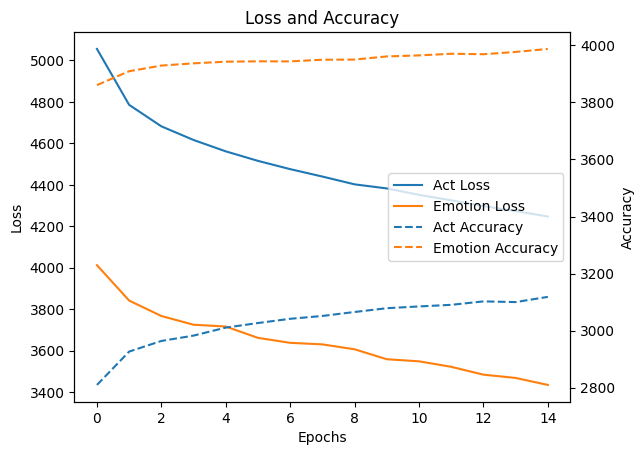

In [56]:
epochs_range=range(epochs)
fig, ax1 = plt.subplots()
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.plot(epochs_range, l1_lis, label="Act Loss")
ax1.plot(epochs_range, l2_lis, label="Emotion Loss")

ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy")
ax2.plot(epochs_range,act_acc_lis , label="Act Accuracy", linestyle="--")
ax2.plot(epochs_range, emotion_acc_lis, label="Emotion Accuracy", linestyle="--")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

plt.title("Loss and Accuracy")
plt.show()